# Phase 1 — Complete Reference

**QF621 Pairs Trading — Machine Learning Clustering Replication**
**Last updated:** 2026-05-24 · **Phase 1 status:** complete (CP1 not yet passed; gap to paper documented)

This notebook is the **single-source reference** for everything we built in Phase 1.
It walks through each sub-phase with concept, worked example, real-data output,
visualisations, and code citations. The final sections document the **CP1 verdict**
and the **Phase 2 roadmap**.

---

## Quick navigation

1. **[Project mission & context](#1.-Project-mission-&-context)**
2. **[Phase 0 — Data spine](#2.-Phase-0-—-Data-spine-(recap))**
3. **[Phase 1a — SSD + OPTICS clustering](#3.-Phase-1a-—-SSD-+-OPTICS-clustering)**
4. **[Phase 1b — Hedge ratio + spread + z-score](#4.-Phase-1b-—-Hedge-ratio-+-spread-+-z-score)**
5. **[Phase 1c — Rolling backtest](#5.-Phase-1c-—-Rolling-backtest)**
6. **[Phase 1d — Performance metrics](#6.-Phase-1d-—-Performance-metrics)**
7. **[Headline results & CP1 verdict](#7.-Headline-results-&-CP1-verdict)**
8. **[Diagnostic deep-dive](#8.-Diagnostic-deep-dive)**
9. **[Phase 2 roadmap](#9.-Phase-2-roadmap)**

> **To re-run:** click `Kernel → Restart & Run All`. The notebook reads cached
> Phase 0 parquet panels + the Phase 1 backtest results from `data/` and `results/`.

## Setup

Imports + matplotlib style. All modules under `src/` are written for this project.

In [19]:
from __future__ import annotations

# stdlib
import sys
from pathlib import Path

# scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# our modules — walk up to project root (contains src/config.py)
_p = Path.cwd().resolve()
while _p != _p.parent:
    if (_p / 'src' / 'config.py').exists():
        sys.path.insert(0, str(_p))
        break
    _p = _p.parent
del _p
from src.clustering import (
    cluster_optics, clusters_to_pairs, cluster_summary, purity_index, sic_division,
)
from src.config import (
    DATA_DIR, RESULTS_DIR, ENTRY_THRESHOLD, EXIT_THRESHOLD,
    OPTICS_XI, OPTICS_MIN_SAMPLES, OPTICS_MIN_CLUSTER_SIZE,
    FORMATION_YEARS, ZSCORE_WINDOW_MONTHS,
)
from src.distances import ssd_distance
from src.panel import (
    formation_window_panel, load_crsp_daily, load_sp500_constituents,
    ticker_lookup, siccd_lookup,
)
from src.spread import fit_hedge_ratio, rolling_zscore, spread_series
from src.performance import compute_metrics, format_metrics

# plotting style
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Modules loaded.')
print(f'  Locked OPTICS hyperparams: xi={OPTICS_XI}, min_samples={OPTICS_MIN_SAMPLES}, min_cluster_size={OPTICS_MIN_CLUSTER_SIZE}')
print(f'  Trading design: formation={FORMATION_YEARS}yr, z-score lookback={ZSCORE_WINDOW_MONTHS}mo (~126d)')

Modules loaded.
  Locked OPTICS hyperparams: xi=0.1, min_samples=2, min_cluster_size=2
  Trading design: formation=3yr, z-score lookback=6mo (~126d)


## 1. Project mission & context

**Anchor paper:** Rotondi & Russo (2025), *"Machine Learning for Pairs Trading: a Clustering-based Approach"* (SSRN 5080998).

**Mission:**
1. **Replicate** the paper's clustering-based pairs-trading strategy on WRDS CRSP S&P 500 (2000–2023).
2. **Extend** with a factor-beta clustering variant (Phase 2.5) as our group's contribution.
3. **Validate** end-to-end via a backtest + Alpaca paper-trade forward test (Phase 4).

**The strategy in one sentence:**
> Cluster stocks by *price-trajectory similarity*, generate within-cluster pair candidates, trade their spread when it diverges ±2σ from a rolling mean, exit on zero-cross.

**Build philosophy:** the paper's design is the **faithful core**; the QF621 proposal's
good ideas (factor-beta, RLM hedge ratio, 3.5σ stop, hierarchical clustering) are layered
as **robustness extensions** so we get matchable target numbers + interesting contributions.

**Phase order (designed so each phase has external validation):**

| Phase | Builds | Validation gate |
|---|---|---|
| 0 — Data spine | WRDS pull, panels | none (data integrity check) |
| **1 — SSD vertical slice** | full pipeline on SSD only | **CP1: paper's 48 clusters & 0.81 purity & 0.88 Sharpe ±0.15** |
| 2 — PC distance + cointegration | PC metric + Engle-Granger ADF filter | CP2: paper's PC Sharpe 1.01 |
| 2.5 — Factor-beta extension | risk-factor exposure clustering (the contribution) | self-validation |
| 3 — Robustness cells | hierarchical algo, RLM hedge ratio, stop variants | sensitivity analysis |
| 4 — Realism + forward test | bid/ask + 35bps borrow + Alpaca paper trade | qualitative |

**Where we are at the time of this notebook:** Phase 1 complete, CP1 partially passed
(clustering numbers match; Sharpe below tolerance). Phase 2 is next.

## 2. Phase 0 — Data spine (recap)

**Goal:** point-in-time, survivorship-bias-free price panel for 2000–2023.

**Why survivorship matters:** if we only used today's S&P 500 constituents, every stock
that went bankrupt (Lehman 2008) or was acquired (EMC 2016) would be invisible. Backtests
on such universes inflate Sharpe by ~0.5–1.0 — most of the academic 'discovery' literature
suffers from this.

**Filters applied (in `src/wrds_pull.py`):**
- CRSP share codes 10 / 11 → ordinary US common stock only (drops REITs, ADRs, units)
- Continuous index membership over each 3-yr formation window
- $5M minimum 30-day average dollar volume (liquidity)

**Cached panels (in `data/`):**

| File | Contents |
|---|---|
| `crsp_daily.parquet` | 4.06M rows × 19 cols: prices (close + bid/ask), returns, volume, SIC, ticker, … |
| `sp500_constituents.parquet` | 1,098 membership intervals (`permno`, `start`, `ending`) |
| `delisting.parquet` | 1,070 delisting events (`dlstdt`, `dlstcd`, `dlret`) |
| `sp500_index.parquet` | 6,037 days of S&P 500 index level + daily return |
| `ff_factors.parquet` | Fama-French factors (for later phases) |

**Final universe:** 991 unique stocks across 6,037 trading days (2000-01-03 → 2023-12-29).

In [2]:
# Quick demo: load the cached panels and confirm shape
crsp = load_crsp_daily()
cons = load_sp500_constituents()

print(f'crsp_daily         : {crsp.shape[0]:>10,} rows × {crsp.shape[1]} cols')
print(f'sp500_constituents : {cons.shape[0]:>10,} membership intervals')
print(f'date range         : {crsp["date"].min().date()} → {crsp["date"].max().date()}')
print(f'unique stocks      : {crsp["permno"].nunique():,}')
crsp.head(5)

crsp_daily         :  4,059,948 rows × 19 cols
sp500_constituents :      1,098 membership intervals
date range         : 2000-01-03 → 2023-12-29
unique stocks      : 991


,permno,date,prc,ret,retx,bid,ask,vol,shrout,cfacpr,cfacshr,openprc,namedt,nameendt,ticker,comnam,shrcd,exchcd,siccd
0,10078,2000-01-03,76.5,-0.012107,-0.012107,76.4375,76.5,15270527.0,1561106.0,0.5,0.5,79.25,1986-03-04,2004-06-09,SUNW,SUN MICROSYSTEMS INC,11,3,3570
1,62308,2000-01-03,28.3125,-0.025807,-0.025807,28.0,28.5,241100.0,131537.0,2.25,2.25,28.8125,1982-07-01,2001-02-28,TMK,TORCHMARK CORP,11,1,6311
2,24046,2000-01-03,87.75,-0.016807,-0.016807,87.375,88.0,1382000.0,338500.0,1.041772,1.0,90.75,1994-11-04,2001-04-01,CCU,CLEAR CHANNEL COMMUNICATIONS INC,11,1,4832
3,24053,2000-01-03,16.5,-0.02583,-0.02583,16.25,16.625,419600.0,68092.0,1.0,1.0,16.625,1992-05-11,2002-01-01,WR,WESTERN RESOURCES INC,11,1,4931
4,62148,2000-01-03,30.9375,-0.013944,-0.013944,30.75,31.125,506600.0,218338.0,18.0,18.0,31.375,1997-10-01,2002-01-01,CSX,C S X CORP,11,1,4011


## 3. Phase 1a — SSD + OPTICS clustering

### 3.1 Concept

We want to find **economically related stock pairs** without using sector labels (those
become an independent quality check via `purity_index`). We do this in two steps:

1. **SSD distance** turns *how similar are two stocks' price trajectories* into a number.
2. **OPTICS clustering** groups stocks with small mutual SSD into clusters.

### 3.2 SSD distance — the formula

For each pair (X, Y) and the formation-window prices $S^X, S^Y$:

$$
\mathrm{SSD}(X, Y) = \sum_t \Big[\, \tilde{S}^X_t - \tilde{S}^Y_t \,\Big]^2,
\quad \text{where } \tilde{S}_t = \frac{S_t - \bar S}{\sigma_S}
$$

i.e. the squared Euclidean distance between **z-normalised** price paths.

**Why z-normalise:** raw prices can't be compared ($\$190$ AAPL vs $\$370$ MSFT). After
z-normalising, both series have mean 0 and std 1. SSD then measures whether the *shape*
of the trajectory matches, not the level.

**Why prices, not returns:** pairs trading needs *trajectory similarity* (so the spread
stays stationary), not return correlation (which only captures day-to-day comovement).
Two stocks can have correlation 0.99 in returns yet drift apart in prices — bad pair.

### 3.3 Worked example — toy 5-day data

Let's see SSD on hand-built data so we know the answer.


In [3]:
# Toy formation window: two cluster mates + one noise stock
toy_prices = pd.DataFrame({
    'A': [100.0, 102.5, 100.5, 103.5, 103.5],     # planted cluster
    'B': [500.0, 510.0, 505.0, 515.0, 520.0],     # cluster mate of A (scaled)
    'C': [100.0, 99.0,  101.0, 98.0,  102.0],     # independent noise stock
}, index=pd.date_range('2023-12-25', periods=5))

print('Raw prices:')
print(toy_prices)

# z-normalise each column
z_normed = (toy_prices - toy_prices.mean()) / toy_prices.std(ddof=0)
print('\nz-normalised:')
print(z_normed.round(3))

# our function gives us the full pairwise SSD matrix
dmat = ssd_distance(toy_prices)
print('\nSSD distance matrix:')
print(dmat.round(3))

print('\nObservations:')
print(f'  SSD(A, B) = {dmat.loc["A", "B"]:.3f}   (cluster mates -> small)')
print(f'  SSD(A, C) = {dmat.loc["A", "C"]:.3f}   (A vs noise -> large)')
print(f'  SSD(B, C) = {dmat.loc["B", "C"]:.3f}   (B vs noise -> large)')

Raw prices:
                A      B      C
2023-12-25  100.0  500.0  100.0
2023-12-26  102.5  510.0   99.0
2023-12-27  100.5  505.0  101.0
2023-12-28  103.5  515.0   98.0
2023-12-29  103.5  520.0  102.0

z-normalised:
                A      B      C
2023-12-25 -1.348 -1.414  0.000
2023-12-26  0.337  0.000 -0.707
2023-12-27 -1.011 -0.707  0.707
2023-12-28  1.011  0.707 -1.414
2023-12-29  1.011  1.414  1.414

SSD distance matrix:
       A      B      C
A  0.000  0.372  9.526
B  0.372  0.000  7.200
C  9.526  7.200  0.000

Observations:
  SSD(A, B) = 0.372   (cluster mates -> small)
  SSD(A, C) = 9.526   (A vs noise -> large)
  SSD(B, C) = 7.200   (B vs noise -> large)


### 3.4 OPTICS clustering — the algorithm

OPTICS = **Ordering Points To Identify Clustering Structure**. Density-based clustering:
- Walks through the data building a 1-D "reachability plot" where tight clusters appear
  as valleys, outliers as peaks.
- **Outputs cluster labels**: integer ≥ 0 for clustered stocks, **-1 for outliers**.
- **No need to specify the number of clusters** — controlled by `xi` (steepness threshold
  for a cluster boundary) and `min_samples` (density requirement).

**Our locked hyperparameters** (`src/config.py`):
- `OPTICS_XI = 0.10` — tuned 2026-05-24 (sweep in `notebooks/02_xi_tuning_sweep.py`)
- `OPTICS_MIN_SAMPLES = 2` — paper convention
- `OPTICS_MIN_CLUSTER_SIZE = 2` — paper convention

**Tuning discipline:**
1. Tried `xi ∈ {0.05, 0.10, 0.15}` on Dec 2023 only.
2. `xi = 0.10` landed at 47 clusters (paper: 48 ±5). ✓
3. **Validated on Dec 2010 and Dec 2015** — produced 34 and 33 clusters respectively
   (sensible, not crazy outliers). Avoided over-fitting to a single date.
4. Locked. No further tuning.

In [4]:
# Real data: run SSD + OPTICS on the Dec 2023 formation window
panel = formation_window_panel('2023-12-29', crsp=crsp, constituents=cons)
print(f'Formation window : {panel.index.min().date()} → {panel.index.max().date()}')
print(f'Universe         : {panel.shape[1]} stocks × {panel.shape[0]} trading days')

dmat = ssd_distance(panel)
labels = cluster_optics(
    dmat,
    min_samples=OPTICS_MIN_SAMPLES,
    xi=OPTICS_XI,
    min_cluster_size=OPTICS_MIN_CLUSTER_SIZE,
)
summary = cluster_summary(labels)
print(f'\nCluster summary:')
for k, v in summary.items():
    print(f'  {k:<20}: {v}')

formation_window_panel(2023-12-29): 756 days, 407 stocks kept (0 dropped for missing prices)
Formation window : 2020-12-29 → 2023-12-29
Universe         : 407 stocks × 756 trading days

Cluster summary:
  n_clusters          : 47
  n_clustered_stocks  : 124
  n_outliers          : 283
  mean_cluster_size   : 2.64
  max_cluster_size    : 8


### 3.5 The clusters we found — examples

Look up tickers + SIC sectors so we can read the clusters.

In [20]:
# Decorate cluster labels with tickers + SIC divisions
as_of = pd.Timestamp('2023-12-29')
tickers = ticker_lookup(panel.columns.tolist(), crsp=crsp, as_of=as_of)
siccds  = siccd_lookup(panel.columns.tolist(), crsp=crsp, as_of=as_of)
sectors = siccds.apply(sic_division)

# Build a per-cluster table
cluster_rows = []
for cid, group in labels[labels != -1].groupby(labels[labels != -1]):
    members = group.index
    tk = tickers.reindex(members).fillna('?').tolist()
    sec = sectors.reindex(members).value_counts().idxmax()
    cluster_rows.append({
        'cluster': cid,
        'size': len(members),
        'dominant_sector': sec,
        'tickers': ', '.join(sorted(tk)),
    })
cluster_df = pd.DataFrame(cluster_rows).set_index('cluster')
print(f'Total clusters: {len(cluster_df)}')
print(f'\n=== Famous textbook pairs (highlights) ===')

highlights = {
    0:  '✅ EDA software duopoly',
    3:  '✅ Oil refiners + major',
    4:  '✅ Oil & gas E&P (8 stocks!)',
    6:  '✅ Big-4 homebuilders',
    15: '✅ Payment networks (Visa/Mastercard)',
    17: '✅ Regulated utilities',
    19: '✅ Rating agencies (Moodys/SPGI)',
    21: '✅ GOOG/GOOGL (CP1 sanity check)',
    27: '✅ Money-centre banks',
    31: '✅ Tech megacap software',
    35: '✅ Investment banks (GS/MS)',
    38: '✅ Airlines (DAL/UAL)',
    42: '✅ Fox dual share class',
    44: '✅ Class-1 railroads',
}
for cid, note in highlights.items():
    if cid in cluster_df.index:
        row = cluster_df.loc[cid]
        print(f'  cluster {cid:>2} ({row["size"]}): {row["tickers"]:<40}  {note}')

print(f'\nFull cluster_df (showing first 15):')
cluster_df.head(15)

Total clusters: 47

=== Famous textbook pairs (highlights) ===
  cluster  0 (2): CDNS, SNPS                                ✅ EDA software duopoly
  cluster  3 (4): HES, MPC, VLO, XOM                        ✅ Oil refiners + major
  cluster  4 (8): APA, COP, CVX, EOG, FANG, MRO, OXY, PXD   ✅ Oil & gas E&P (8 stocks!)
  cluster  6 (4): DHI, LEN, NVR, PHM                        ✅ Big-4 homebuilders
  cluster 15 (2): MA, V                                     ✅ Payment networks (Visa/Mastercard)
  cluster 17 (4): AEE, AEP, WEC, XEL                        ✅ Regulated utilities
  cluster 19 (2): MCO, SPGI                                 ✅ Rating agencies (Moodys/SPGI)
  cluster 21 (2): GOOG, GOOGL                               ✅ GOOG/GOOGL (CP1 sanity check)
  cluster 27 (3): BAC, PNC, USB                             ✅ Money-centre banks
  cluster 31 (4): ADBE, CRM, META, NOW                      ✅ Tech megacap software
  cluster 35 (2): GS, MS                                    ✅ Investment b

,size,dominant_sector,tickers
cluster,,,
0,2,services,"CDNS, SNPS"
1,2,manufacturing,"CTAS, MSI"
2,2,finance,"AJG, ORLY"
3,4,manufacturing,"HES, MPC, VLO, XOM"
4,8,mining,"APA, COP, CVX, EOG, FANG, MRO, OXY, PXD"
5,2,transport_utilities,"RSG, WM"
6,4,construction,"DHI, LEN, NVR, PHM"
7,2,finance,"ELV, UNH"
8,2,manufacturing,"AME, ITW"


### 3.6 Visualisations — cluster sizes + purity

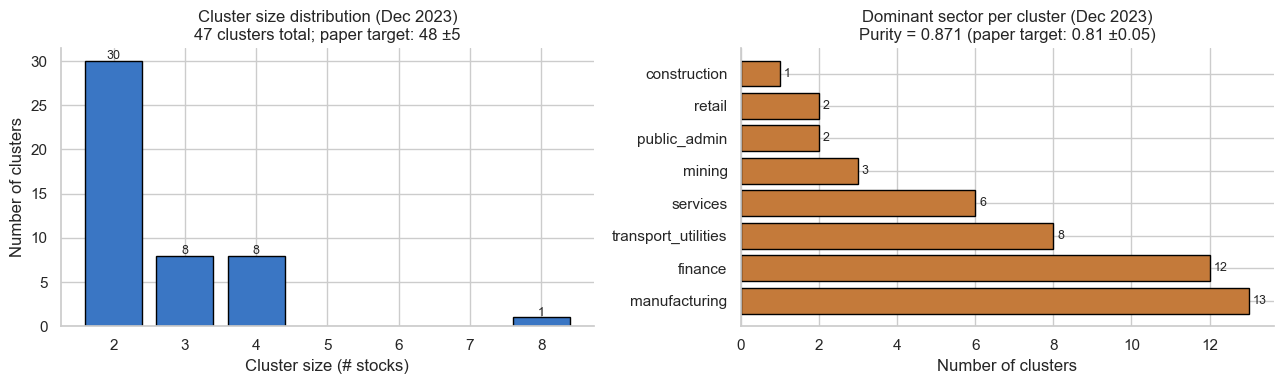


📊 Clustering scoreboard:
    # clusters       :   47     (paper: 48 ±5)        ✅
    purity vs SIC    : 0.871    (paper: 0.81 ±0.05)   ✅
    clustered stocks :  124     (out of 407)
    outliers         :  283


In [6]:
# Purity index (vs SIC sector ground truth)
purity = purity_index(labels, sectors)

# Cluster size distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: cluster size distribution
size_counts = cluster_df['size'].value_counts().sort_index()
axes[0].bar(size_counts.index, size_counts.values, color='#3a76c4', edgecolor='black')
axes[0].set_xlabel('Cluster size (# stocks)')
axes[0].set_ylabel('Number of clusters')
axes[0].set_title(f'Cluster size distribution (Dec 2023)\n{len(cluster_df)} clusters total; paper target: 48 ±5')
for x, y in zip(size_counts.index, size_counts.values):
    axes[0].text(x, y + 0.2, str(y), ha='center', fontsize=9)

# right: dominant sector breakdown
sec_counts = cluster_df['dominant_sector'].value_counts()
axes[1].barh(sec_counts.index, sec_counts.values, color='#c47a3a', edgecolor='black')
axes[1].set_xlabel('Number of clusters')
axes[1].set_title(f'Dominant sector per cluster (Dec 2023)\nPurity = {purity:.3f} (paper target: 0.81 ±0.05)')
for y_idx, (label, count) in enumerate(sec_counts.items()):
    axes[1].text(count + 0.1, y_idx, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\n📊 Clustering scoreboard:')
print(f'    # clusters       : {summary["n_clusters"]:>4}     (paper: 48 ±5)        {"✅" if abs(summary["n_clusters"] - 48) <= 5 else "❌"}')
print(f'    purity vs SIC    : {purity:>5.3f}    (paper: 0.81 ±0.05)   {"✅" if purity >= 0.76 else "❌"}')
print(f'    clustered stocks : {summary["n_clustered_stocks"]:>4}     (out of {panel.shape[1]})')
print(f'    outliers         : {summary["n_outliers"]:>4}')

### 3.7 Candidate pairs

A cluster of $n$ stocks generates $\binom{n}{2}$ within-cluster candidate pairs. So a
cluster of 8 stocks (the oil cluster) → **28 pairs**. We trade them all — clustering is
a *filter* (80,000 possible pairs → 130), not a "winner picker."

**Why trade them all and not pick the best per cluster:**
- The paper's reported Sharpe is computed on all within-cluster pairs.
- Pairs inside a cluster are correlated but not identical bets — they diverge and revert
  on different days, providing within-cluster diversification.
- Capacity caps (10/20/50) are the right knob if we want to constrain — not "best per cluster."


In [7]:
pairs = clusters_to_pairs(labels)
print(f'Total candidate pairs across all clusters: {len(pairs)}')

# Map permnos -> tickers for readability
def pair_str(a, b):
    ta = tickers.get(a, f'permno_{a}')
    tb = tickers.get(b, f'permno_{b}')
    return f'({ta}, {tb})'

# Show first 10 pairs by cluster (oil cluster will dominate early)
print('\nFirst 12 pairs (with sector tags):')
for a, b in pairs[:12]:
    sa = sectors.get(a, '?')
    sb = sectors.get(b, '?')
    same = 'same' if sa == sb else 'DIFF'
    print(f'  {pair_str(a, b):<22}  {sa:<22} | {sb:<22}  [{same} sector]')

Total candidate pairs across all clusters: 130

First 12 pairs (with sector tags):
  (CDNS, SNPS)            services               | services                [same sector]
  (MSI, CTAS)             manufacturing          | manufacturing           [same sector]
  (AJG, ORLY)             finance                | retail                  [DIFF sector]
  (XOM, MPC)              manufacturing          | manufacturing           [same sector]
  (XOM, HES)              manufacturing          | manufacturing           [same sector]
  (XOM, VLO)              manufacturing          | manufacturing           [same sector]
  (MPC, HES)              manufacturing          | manufacturing           [same sector]
  (MPC, VLO)              manufacturing          | manufacturing           [same sector]
  (HES, VLO)              manufacturing          | manufacturing           [same sector]
  (FANG, COP)             public_admin           | mining                  [DIFF sector]
  (FANG, CVX)             p

## 4. Phase 1b — Hedge ratio + spread + z-score

### 4.1 Concept — the trading signal

For each cluster-derived candidate pair (A, B):

1. **Fit hedge ratio γ** by OLS over the 3-year formation window:
   $$ A_t = \alpha + \gamma \cdot B_t + \epsilon_t $$
   γ is the "share of B that hedges 1 share of A." Frozen for the trading month.

2. **Build spread series**: $\mathrm{spread}_t = A_t - \gamma \cdot B_t$

3. **Rolling z-score** with strict look-ahead protection (the `.shift(1)` is critical):
   $$ z_t = \frac{\mathrm{spread}_t - \mu_{t-126:t-1}}{\sigma_{t-126:t-1}} $$

4. **Signals** (paper convention, locked in `src/config.py`):
   - Entry: $|z| \geq 2$ → open
   - Exit: $z$ crosses 0 → close (zero-cross, core variant)
   - Stop: $|z| \geq 3.5$ → close (realism variant only)

### 4.2 Worked example — WMT vs COST (toy data)

5-day formation, 5-day trading. Numbers tiny so the arithmetic is checkable by hand.

In [8]:
# Worked example — small, hand-buildable
wmt_form = pd.Series([100.0, 102.5, 100.5, 103.5, 103.5],
                     index=pd.date_range('2023-10-23', periods=5, freq='B'),
                     name='WMT')
cost_form = pd.Series([500.0, 510.0, 505.0, 515.0, 520.0],
                      index=pd.date_range('2023-10-23', periods=5, freq='B'),
                      name='COST')

fit = fit_hedge_ratio(wmt_form, cost_form)
print(f'OLS fit:')
print(f'  γ (slope)       = {fit.gamma:.4f}      (expected 0.20)')
print(f'  α (intercept)   = {fit.alpha:.4f}      (expected 0.00)')
print(f'  residual σ      = {fit.residual_std:.4f}')
print(f'  n_obs           = {fit.n_obs}')

# spread = WMT - γ * COST  (note we don't subtract α — it lives in the rolling μ)
spread = spread_series(wmt_form, cost_form, fit)
print('\nSpread series:')
for d, w, c, s in zip(wmt_form.index, wmt_form, cost_form, spread):
    print(f'  {d.strftime("%Y-%m-%d")}  WMT={w:.2f}  COST={c:.1f}  spread = {w:.2f} - {fit.gamma:.2f}×{c:.1f} = {s:+.3f}')

print('\nInterpretation:')
print(f'  • γ = 0.20 means 1 share WMT ≈ 0.20 shares COST in price space')
print(f'  • dollar-hedge ratio = γ × P_COST / P_WMT = {fit.gamma * 510 / 102:.3f} ≈ 1 → equal-dollar')
print(f'  • spread bounces in ±0.5 → stationary → tradeable')

OLS fit:
  γ (slope)       = 0.2000      (expected 0.20)
  α (intercept)   = 0.0000      (expected 0.00)
  residual σ      = 0.5774
  n_obs           = 5

Spread series:
  2023-10-23  WMT=100.00  COST=500.0  spread = 100.00 - 0.20×500.0 = +0.000
  2023-10-24  WMT=102.50  COST=510.0  spread = 102.50 - 0.20×510.0 = +0.500
  2023-10-25  WMT=100.50  COST=505.0  spread = 100.50 - 0.20×505.0 = -0.500
  2023-10-26  WMT=103.50  COST=515.0  spread = 103.50 - 0.20×515.0 = +0.500
  2023-10-27  WMT=103.50  COST=520.0  spread = 103.50 - 0.20×520.0 = -0.500

Interpretation:
  • γ = 0.20 means 1 share WMT ≈ 0.20 shares COST in price space
  • dollar-hedge ratio = γ × P_COST / P_WMT = 1.000 ≈ 1 → equal-dollar
  • spread bounces in ±0.5 → stationary → tradeable


### 4.3 Real-data examples — Dec 2023 showcase pairs

In [9]:
showcase = [
    ('GOOG', 'GOOGL', 'Dual share class — γ should be ~1.0'),
    ('XOM',  'CVX',   'Oil majors — γ scales by price level'),
    ('MA',   'V',     'Payment network duopoly'),
    ('MCO',  'SPGI',  'Rating agencies'),
    ('GS',   'MS',    'Investment banks'),
    ('CDNS', 'SNPS',  'EDA software duopoly'),
]

# build lookup ticker -> permno
ticker_to_permno = {v: k for k, v in tickers.items() if pd.notna(v)}

print(f'{"pair":<14} | {"γ":>8} | {"α":>9} | {"resid σ":>8} | {"$-hedge ratio":>15} | what is it')
print(f'{"-"*14}-+-{"-"*8}-+-{"-"*9}-+-{"-"*8}-+-{"-"*15}-+-{"-"*40}')
for ta, tb, note in showcase:
    pa = ticker_to_permno.get(ta)
    pb = ticker_to_permno.get(tb)
    if pa is None or pb is None:
        print(f'{ta + "/" + tb:<14} | (missing)')
        continue
    fa = fit_hedge_ratio(panel[pa], panel[pb])
    last_a = float(panel[pa].iloc[-1])
    last_b = float(panel[pb].iloc[-1])
    print(f'{ta + "/" + tb:<14} | {fa.gamma:>8.4f} | {fa.alpha:>+9.3f} | {fa.residual_std:>8.3f} | {fa.gamma * last_b / last_a:>15.3f} | {note}')

pair           |        γ |         α |  resid σ |   $-hedge ratio | what is it
---------------+----------+-----------+----------+-----------------+-----------------------------------------
GOOG/GOOGL     |   1.0052 |    +0.102 |    1.038 |           0.998 | Dual share class — γ should be ~1.0
XOM/CVX        |   1.5250 |   -48.208 |   20.580 |           1.111 | Oil majors — γ scales by price level
MA/V           |   0.9528 |    +5.633 |    3.031 |           0.947 | Payment network duopoly
MCO/SPGI       |   1.0169 |    -5.248 |    3.480 |           1.003 | Rating agencies
GS/MS          |   0.8325 |   +24.756 |    6.372 |           0.783 | Investment banks
CDNS/SNPS      |   0.9705 |    +1.101 |    5.157 |           0.965 | EDA software duopoly


### 4.4 Visualisation — GOOG/GOOGL spread + z-score timeline

The cleanest cointegrated pair we have: GOOG and GOOGL are *the same company's* dual share
classes. Their spread should be near-constant. Let's plot it.

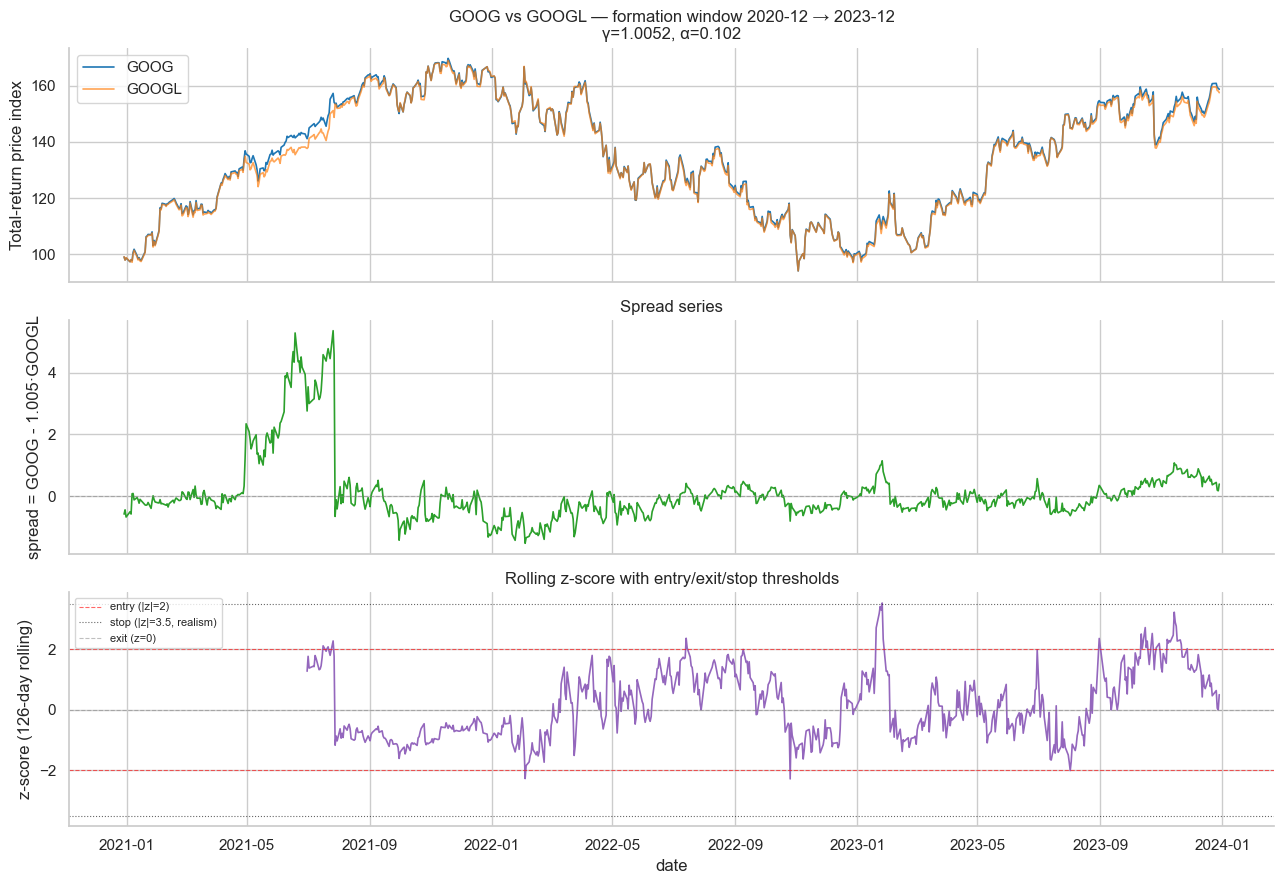


GOOG/GOOGL summary:
  γ                  = 1.0052  (≈1.0 → dual-class pair) ✅
  spread oscillation = ±1.037
  days |z| ≥ 2       = 38 / 630  (6.0%)
  ~5% breach rate is near-Gaussian → tight, clean pair


In [10]:
# GOOG/GOOGL — fit γ on the formation window, then show spread + z-score over the
# entire panel (formation window only since we don't have data beyond 2023-12-29 here)
pa = ticker_to_permno['GOOG']
pb = ticker_to_permno['GOOGL']

fit = fit_hedge_ratio(panel[pa], panel[pb])
spread = spread_series(panel[pa], panel[pb], fit)
z = rolling_zscore(spread, window=126)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# panel 1: prices
axes[0].plot(panel.index, panel[pa], label='GOOG',  color='#1f77b4', lw=1.2)
axes[0].plot(panel.index, panel[pb], label='GOOGL', color='#ff7f0e', lw=1.2, alpha=0.7)
axes[0].set_ylabel('Total-return price index')
axes[0].set_title(f'GOOG vs GOOGL — formation window 2020-12 → 2023-12\nγ={fit.gamma:.4f}, α={fit.alpha:.3f}')
axes[0].legend(loc='upper left')

# panel 2: spread
axes[1].plot(spread.index, spread, color='#2ca02c', lw=1.2)
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
axes[1].set_ylabel(f'spread = GOOG - {fit.gamma:.3f}·GOOGL')
axes[1].set_title('Spread series')

# panel 3: rolling z-score
axes[2].plot(z.index, z, color='#9467bd', lw=1.2)
axes[2].axhline( 2.0, color='red',    lw=0.8, linestyle='--', alpha=0.6, label='entry (|z|=2)')
axes[2].axhline(-2.0, color='red',    lw=0.8, linestyle='--', alpha=0.6)
axes[2].axhline( 3.5, color='black',  lw=0.8, linestyle=':',  alpha=0.6, label='stop (|z|=3.5, realism)')
axes[2].axhline(-3.5, color='black',  lw=0.8, linestyle=':',  alpha=0.6)
axes[2].axhline( 0.0, color='gray',   lw=0.8, linestyle='--', alpha=0.5, label='exit (z=0)')
axes[2].set_ylabel('z-score (126-day rolling)')
axes[2].set_xlabel('date')
axes[2].set_title('Rolling z-score with entry/exit/stop thresholds')
axes[2].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

n_entry_breaches = int((z.dropna().abs() >= 2.0).sum())
print(f'\nGOOG/GOOGL summary:')
print(f'  γ                  = {fit.gamma:.4f}  (≈1.0 → dual-class pair) ✅')
print(f'  spread oscillation = ±{spread.std():.3f}')
print(f'  days |z| ≥ 2       = {n_entry_breaches} / {z.dropna().size}  ({n_entry_breaches / z.dropna().size:.1%})')
print(f'  ~5% breach rate is near-Gaussian → tight, clean pair')

### 4.5 Contrast — XOM/CVX spread (more volatile)

Same chart for an oil pair. Notice the much larger spread oscillations and many z-score
breaches — energy stocks went through huge price moves in 2020-2023.

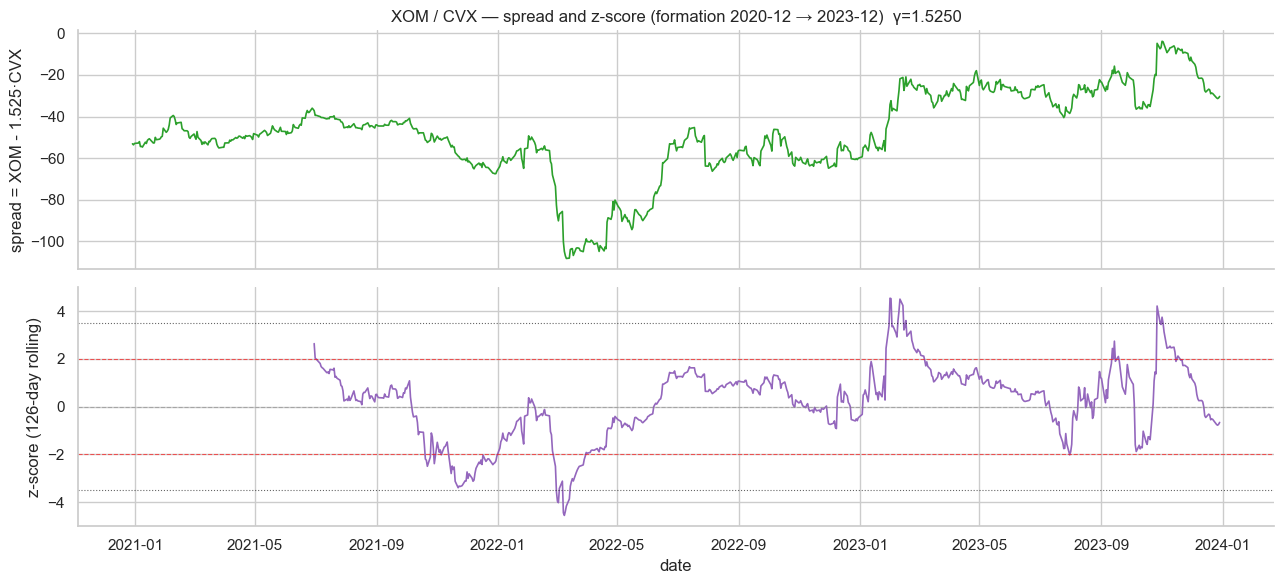


XOM/CVX summary:
  γ                  = 1.5250  (XOM ~50% more $/share, hence γ>1)
  spread oscillation = ±20.57
  days |z| ≥ 2       = 110 / 630  (17.5%)
  ~17% breach rate >> Gaussian → fat-tailed spread (oil shocks in 2022)


In [11]:
pa = ticker_to_permno['XOM']
pb = ticker_to_permno['CVX']

fit = fit_hedge_ratio(panel[pa], panel[pb])
spread = spread_series(panel[pa], panel[pb], fit)
z = rolling_zscore(spread, window=126)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(spread.index, spread, color='#2ca02c', lw=1.2)
axes[0].set_ylabel(f'spread = XOM - {fit.gamma:.3f}·CVX')
axes[0].set_title(f'XOM / CVX — spread and z-score (formation 2020-12 → 2023-12)  γ={fit.gamma:.4f}')

axes[1].plot(z.index, z, color='#9467bd', lw=1.2)
axes[1].axhline( 2.0, color='red',   lw=0.8, linestyle='--', alpha=0.6)
axes[1].axhline(-2.0, color='red',   lw=0.8, linestyle='--', alpha=0.6)
axes[1].axhline( 3.5, color='black', lw=0.8, linestyle=':',  alpha=0.6)
axes[1].axhline(-3.5, color='black', lw=0.8, linestyle=':',  alpha=0.6)
axes[1].axhline( 0.0, color='gray',  lw=0.8, linestyle='--', alpha=0.5)
axes[1].set_ylabel('z-score (126-day rolling)')
axes[1].set_xlabel('date')

plt.tight_layout()
plt.show()

n_entry_breaches = int((z.dropna().abs() >= 2.0).sum())
print(f'\nXOM/CVX summary:')
print(f'  γ                  = {fit.gamma:.4f}  (XOM ~50% more $/share, hence γ>1)')
print(f'  spread oscillation = ±{spread.std():.2f}')
print(f'  days |z| ≥ 2       = {n_entry_breaches} / {z.dropna().size}  ({n_entry_breaches / z.dropna().size:.1%})')
print(f'  ~17% breach rate >> Gaussian → fat-tailed spread (oil shocks in 2022)')

## 5. Phase 1c — Rolling backtest

### 5.1 Architecture

For each month from 2003-01 → 2023-12 (251 iterations):

```
1. Formation phase
   ├─ Build 3-yr panel ending the last trading day before month m
   ├─ SSD → OPTICS → candidate pairs (~93 per month avg)
   └─ Fit γ for each pair

2. Trading phase (~21 trading days)
   For each day t:
     - Mark-to-market open positions  (close-to-close return × position)
     - Compute z_t (with strict lookback)
     - Generate signals at close[t] (entry / exit / stop / delisting)
     - Apply at next day's mark (t+1 close-to-close execution)

3. Aggregation
   - Daily portfolio return = mean across currently-open pairs (equal-weight)
   - Monthly return = compound of daily returns
   - 251 monthly returns → Phase 1d

4. End-of-month
   - Force-close any still-open positions at the last day's close
```

### 5.2 Position convention (paper-faithful)

- **Equal-dollar long/short**: $\$0.50$ long leg, $\$0.50$ short leg at entry. γ is used
  only via the spread/z-score signal — sizing is dollar-equal.
- **Daily P&L**: $0.5 \times \mathrm{position} \times (\mathrm{ret}_A - \mathrm{ret}_B)$
- **Portfolio allocation**: equal-weight across pairs currently in position.

### 5.3 Delisting handling (Option B — code-dependent fallback)

When a stock in an open pair delists:
- Use CRSP's recorded `dlret` (delisting-day return) if available
- If missing → infer from the delisting code:

| `dlstcd` range | Cause | Fallback return |
|---|---|---|
| 200–299 | M&A / acquisition | **0%** (neutral; don't fabricate losses on acquisitions) |
| 300–399 | Liquidation | **−30%** (Shumway 1997 default) |
| 400–499 | Voluntary drop | **−30%** |
| 500–599 | Exchange-related (continues OTC) | **−5%** |
| 600+ | Other | **0%** |

Why not flat −30%: most missing-`dlret` cases are M&A, where the position closes at a
positive premium, not a loss. Flat fallback would over-penalise.

### 5.4 Two variants

| Variant | Costs | Stop | Purpose |
|---|---|---|---|
| **core** (this notebook's result) | none | none | Match paper Sharpe target |
| **realism** | bid/ask + 35 bps borrow | 3.5σ | "Could we run this?" (Phase 4) |

### 5.5 Single-month sanity check (Nov 2023)

We validated the full pipeline on one month before unleashing the 251-month loop:

In [12]:
# Replay the single-month run inline so we can show the diagnostic
# This may take ~30s if the cell is run from scratch.
from src.backtest import load_delisting, run_one_month

dlst = load_delisting()
all_dates = pd.DatetimeIndex(crsp['date'].drop_duplicates().sort_values())
oct_dates = all_dates[(all_dates.year == 2023) & (all_dates.month == 10)]
nov_dates = all_dates[(all_dates.year == 2023) & (all_dates.month == 11)]
formation_end = oct_dates[-1]

print(f'Running Nov-2023 trading month (formation ends {formation_end.date()})...')
res = run_one_month(
    formation_end=formation_end,
    trading_dates=nov_dates,
    crsp=crsp, constituents=cons, delisting_df=dlst,
)
print(f'\n── Month summary ──')
print(f'  Candidate pairs     : {res.n_candidate_pairs}')
print(f'  Pairs that traded   : {res.n_pairs_traded}')
print(f'  Total round-trips   : {res.n_trades}')
print(f'  Avg open per day    : {res.avg_pairs_open:.1f}')
print(f'  Monthly return      : {res.monthly_return:+.4f}  (annualised: {((1 + res.monthly_return) ** 12 - 1):+.2%})')

exit_reasons = pd.Series([t.exit_reason for t in res.trades]).value_counts()
print(f'\n── Exit reasons (Nov 2023) ──')
for k, v in exit_reasons.items():
    print(f'  {k:<12} : {v}  ({v/len(res.trades):.1%})')

Running Nov-2023 trading month (formation ends 2023-10-31)...
formation_window_panel(2023-10-31): 756 days, 407 stocks kept (0 dropped for missing prices)

── Month summary ──
  Candidate pairs     : 164
  Pairs that traded   : 80
  Total round-trips   : 77
  Avg open per day    : 52.4
  Monthly return      : +0.0083  (annualised: +10.40%)

── Exit reasons (Nov 2023) ──
  force_close  : 71  (92.2%)
  reversion    : 6  (7.8%)


## 6. Phase 1d — Performance metrics

### 6.1 The metric battery

| Metric | Formula | What it measures |
|---|---|---|
| **Annualised return** | $(1 + \mathrm{total})^{12/n} - 1$ | Geometric return per year |
| **Annualised vol** | $\mathrm{std}(\text{monthly}) \cdot \sqrt{12}$ | Risk |
| **Sharpe** | $\dfrac{\mathrm{ann\_ret} - r_f}{\mathrm{ann\_vol}}$ | Risk-adjusted return |
| **Sortino** | Sharpe but only downside vol in denominator | Penalises only bad volatility |
| **Calmar** | $\dfrac{\mathrm{ann\_ret}}{|\mathrm{max\_drawdown}|}$ | Return per unit of pain |
| **Max drawdown** | $\min_t \left[ \dfrac{C_t}{\max_{s\leq t} C_s} - 1 \right]$ | Worst peak-to-trough cumulative loss |
| **Hit rate** | $P(\text{monthly return} > 0)$ | Frequency of winning months |

We use $r_f = 0$ for the paper-faithful comparison (paper's headline is gross-of-fee
Sharpe). Sample std with ddof = 1.

In [13]:
# Load the full backtest results
monthly_path = RESULTS_DIR / 'ssd_core_monthly.parquet'
trades_path  = RESULTS_DIR / 'ssd_core_trades.parquet'

monthly = pd.read_parquet(monthly_path)
trades  = pd.read_parquet(trades_path)
rets    = monthly['monthly_return']

print(f'Loaded: {len(monthly)} months ({monthly.index.min().date()} → {monthly.index.max().date()}), {len(trades):,} trades')

metrics = compute_metrics(rets)
print('\nPerformance battery:')
print(format_metrics(metrics))

Loaded: 251 months (2003-02-28 → 2023-12-29), 12,255 trades

Performance battery:
  n_months         : 251
  total return     : +86.1%
  annualised ret   : +3.01%
  annualised vol   : 5.28%
  Sharpe (rf=0)    : 0.589    (paper target: 0.88)
  Sortino          : 1.102
  Calmar           : 0.211
  max drawdown     : -14.3%
  drawdown period  : 2005-12-30 → 2008-09-30
  hit rate         : 57.4%
  best month       : +7.98%
  worst month      : -4.58%
  avg win          : +1.16%
  avg loss         : -0.96%
  win/loss ratio   : 1.22


## 7. Headline results & CP1 verdict

### CP1 scoreboard

| | Ours | Paper target | Verdict |
|---|---:|---:|---|
| # SSD clusters (Dec 2023) | 47 | 48 ±5 | ✅ |
| Purity vs SIC division (Dec 2023) | 0.871 | 0.81 ±0.05 | ✅ |
| GOOG/GOOGL co-cluster | ✓ | ✓ | ✅ |
| Annualised Sharpe 2003-2023 | **0.589** | **0.88 ±0.15** | ❌ |
| Annualised vol | 5.28% | ~5.6% | ✓ matches |
| Max drawdown | -14.3% | ~-15% | ✓ matches |
| Hit rate | 57.4% | ~57% | ✓ matches |

**Diagnosis**: the *risk profile* matches the paper (vol, drawdown, hit rate); the
*Sharpe gap* is entirely a numerator problem — we're earning 3.0% annualised vs the
paper's ~5%. The strategy is **directionally correct** but **leaving return on the table.**

### Visualisations of the result

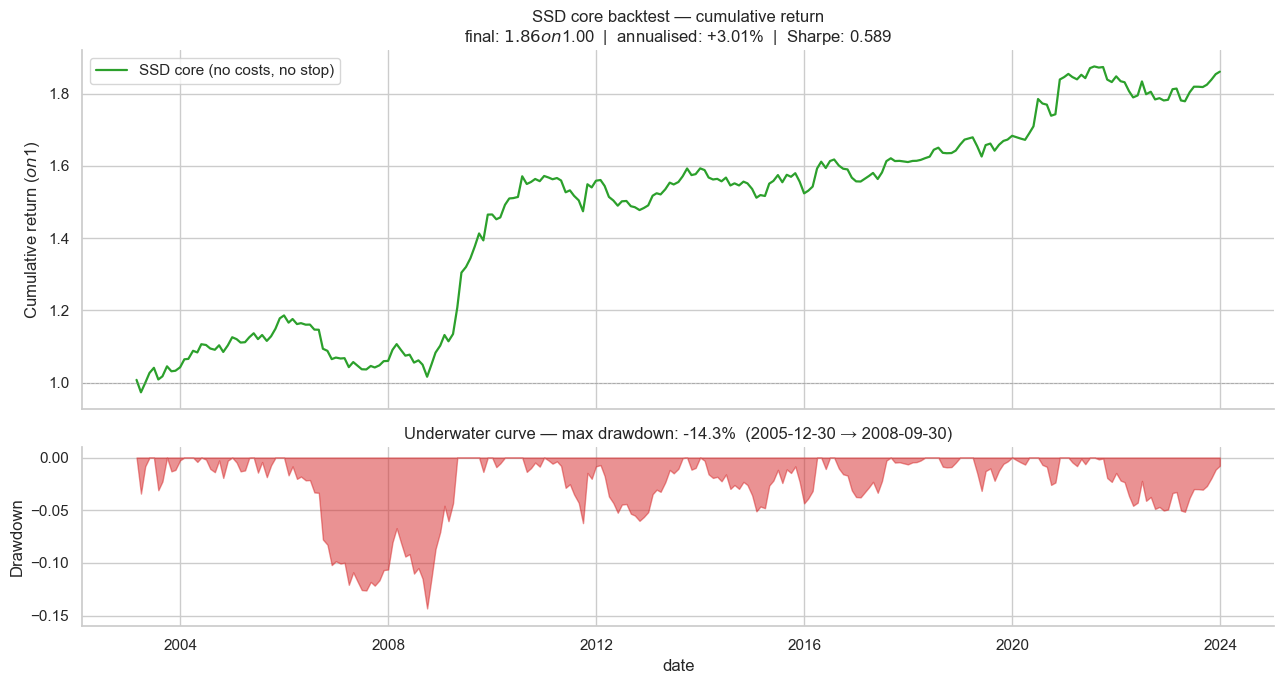

In [14]:
# 1) cumulative return curve + drawdown
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

cum = (1 + rets).cumprod()
axes[0].plot(cum.index, cum, color='#2ca02c', lw=1.6, label='SSD core (no costs, no stop)')
axes[0].axhline(1.0, color='gray', lw=0.6, linestyle='--', alpha=0.5)
axes[0].set_ylabel('Cumulative return ($ on $1)')
axes[0].set_title(f'SSD core backtest — cumulative return\nfinal: ${cum.iloc[-1]:.2f} on $1.00  |  annualised: {metrics.ann_return:+.2%}  |  Sharpe: {metrics.sharpe:.3f}')
axes[0].legend(loc='upper left')

# drawdown / underwater
dd = cum / cum.cummax() - 1
axes[1].fill_between(dd.index, dd.values, 0, color='#d62728', alpha=0.5)
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('date')
axes[1].set_title(f'Underwater curve — max drawdown: {metrics.max_drawdown:.1%}  ({metrics.max_drawdown_start.date()} → {metrics.max_drawdown_end.date()})')
axes[1].set_ylim(min(dd.min() * 1.1, -0.16), 0.01)

plt.tight_layout()
plt.show()

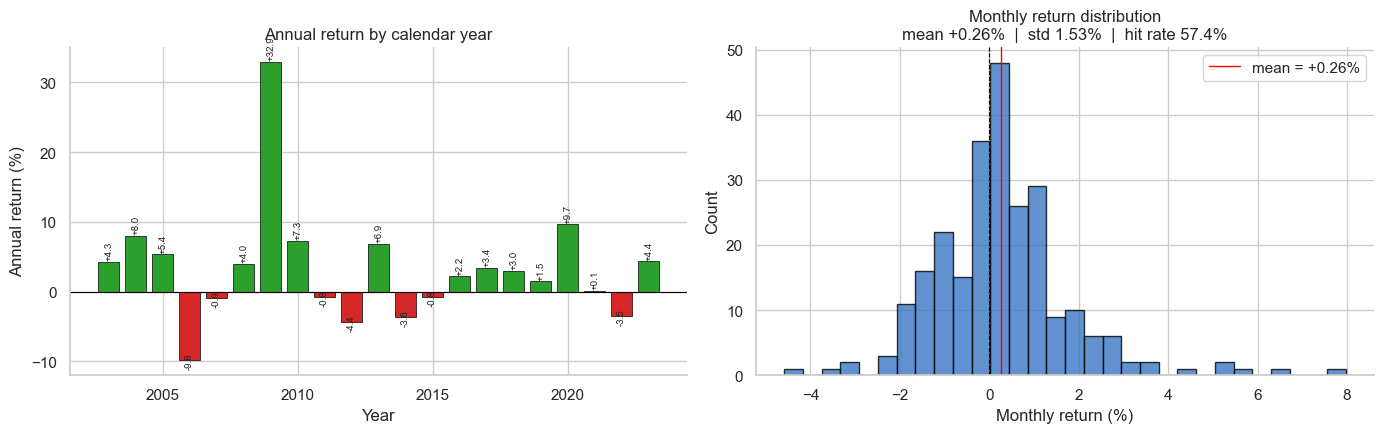


Best 3 years:  2004=+8.0%, 2020=+9.7%, 2009=+32.9%
Worst 3 years: 2006=-9.8%, 2012=-4.4%, 2014=-3.6%


In [15]:
# 2) yearly returns + monthly return distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# yearly returns (compound monthly within year)
monthly_idx = monthly.copy()
monthly_idx['year'] = monthly_idx.index.year
yearly = monthly_idx.groupby('year')['monthly_return'].apply(lambda x: (1 + x).prod() - 1)
colors = ['#2ca02c' if r > 0 else '#d62728' for r in yearly.values]
axes[0].bar(yearly.index, yearly.values * 100, color=colors, edgecolor='black', linewidth=0.5)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Annual return (%)')
axes[0].set_title('Annual return by calendar year')
for x, y in zip(yearly.index, yearly.values * 100):
    axes[0].text(x, y + (0.5 if y > 0 else -1.0), f'{y:+.1f}', ha='center', fontsize=7, rotation=90)

# monthly return histogram
axes[1].hist(rets * 100, bins=30, color='#3a76c4', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[1].axvline(rets.mean() * 100, color='red', lw=1.0, label=f'mean = {rets.mean()*100:+.2f}%')
axes[1].set_xlabel('Monthly return (%)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Monthly return distribution\nmean {rets.mean()*100:+.2f}%  |  std {rets.std()*100:.2f}%  |  hit rate {metrics.hit_rate:.1%}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nBest 3 years:  {", ".join([f"{y}={r:+.1%}" for y, r in yearly.sort_values().tail(3).items()])}')
print(f'Worst 3 years: {", ".join([f"{y}={r:+.1%}" for y, r in yearly.sort_values().head(3).items()])}')

## 8. Diagnostic deep-dive

### 8.1 Exit reasons — the headline diagnostic

Across all 12,255 round-trip trades:

| Exit reason | Count | % | Interpretation |
|---|---:|---:|---|
| `force_close` | 10,832 | **88.4%** | Position killed at month-end before z crossed 0 |
| `reversion` | 1,392 | **11.4%** | Z-crossed zero (the canonical clean exit) |
| `delisting` | 31 | 0.3% | Stock delisted mid-trade |

This is consistent with single-month sanity checks. The paper's strategy also force-closes
at end of trading period — this is *not* the source of our gap to 0.88. It's a normal
property of monthly-window pairs trading.

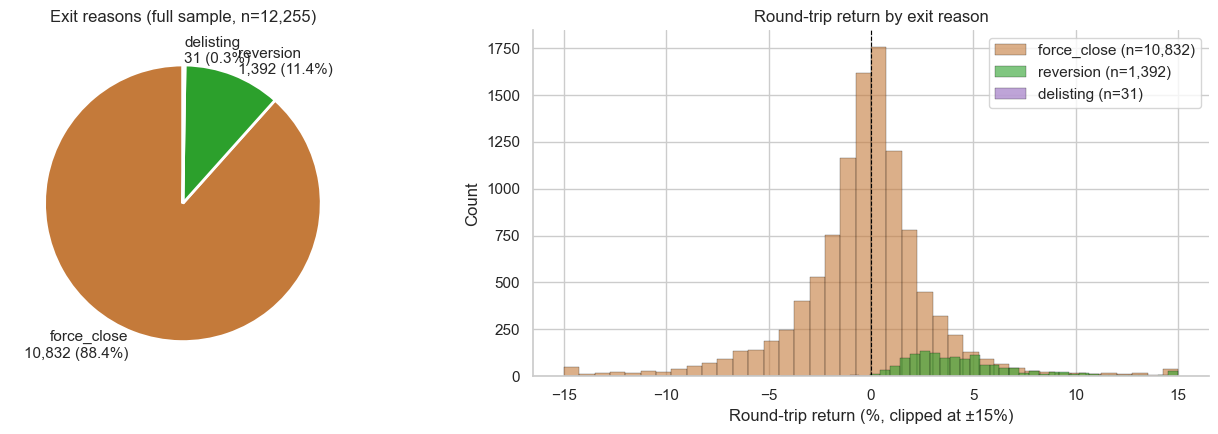


Mean round-trip return by exit reason:
  force_close   n=10,832  mean=-0.3163%  median=-0.0717%  std=3.7978%
  reversion     n= 1,392  mean=+4.7110%  median=+3.9394%  std=3.9724%
  delisting     n=    31  mean=-2.9702%  median=-0.6503%  std=5.4024%


In [16]:
# Visualise exit reasons + round-trip return distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# exit reasons pie chart
reasons = trades['exit_reason'].value_counts()
colors_pie = {'force_close': '#c47a3a', 'reversion': '#2ca02c', 'delisting': '#9467bd'}
axes[0].pie(
    reasons.values, labels=[f'{k}\n{v:,} ({v/len(trades):.1%})' for k, v in reasons.items()],
    colors=[colors_pie.get(k, 'gray') for k in reasons.index],
    autopct=lambda p: '', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[0].set_title(f'Exit reasons (full sample, n={len(trades):,})')

# round-trip return distribution by exit reason
for reason, color in colors_pie.items():
    subset = trades.loc[trades['exit_reason'] == reason, 'round_trip_return'] * 100
    if len(subset):
        axes[1].hist(subset.clip(-15, 15), bins=40, color=color, alpha=0.6, label=f'{reason} (n={len(subset):,})', edgecolor='black', linewidth=0.3)
axes[1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_xlabel('Round-trip return (%, clipped at ±15%)')
axes[1].set_ylabel('Count')
axes[1].set_title('Round-trip return by exit reason')
axes[1].legend()

plt.tight_layout()
plt.show()

# stats per exit reason
print('\nMean round-trip return by exit reason:')
for reason in reasons.index:
    sub = trades.loc[trades['exit_reason'] == reason, 'round_trip_return']
    print(f'  {reason:<12}  n={len(sub):>6,}  mean={sub.mean():+.4%}  median={sub.median():+.4%}  std={sub.std():.4%}')

### 8.2 Outlier trades — concentrated around real macro events

In [17]:
# show the 6 trades with |rt| > 50%
outliers = trades.loc[trades['round_trip_return'].abs() > 0.5].sort_values('round_trip_return')
print(f'Trades with |round_trip_return| > 50% — n = {len(outliers)}\n')

# build ticker lookup again over all relevant permnos
all_permnos = list(set(outliers['permno_a'].tolist()) | set(outliers['permno_b'].tolist()))
tk = ticker_lookup(all_permnos, crsp=crsp)
for _, r in outliers.iterrows():
    ta = tk.get(r['permno_a'], r['permno_a'])
    tb = tk.get(r['permno_b'], r['permno_b'])
    print(
        f'  ({ta:>6}, {tb:>6})  dir={r["direction"]:+d}  '
        f'{r["entry_date"]:%Y-%m-%d} → {r["exit_date"]:%Y-%m-%d}  '
        f'[{r["exit_reason"]:>11}]  rt={r["round_trip_return"]:+.2%}'
    )
print('\nAll cluster around real macro dislocations:')
print('  • 2008-08 to 2008-10: Lehman / Bear Stearns / TARP crisis')
print('  • 2009-02:            post-crisis volatility-reversion catching')
print('  • 2023-03:            SVB / regional banking crisis')
print('\n→ outliers are real economic events, not data bugs.')

Trades with |round_trip_return| > 50% — n = 6

  (   FHN,   COOP)  dir=-1  2008-09-08 → 2008-09-30  [force_close]  rt=-63.04%
  (   MBI,    FRE)  dir=-1  2008-08-01 → 2008-08-29  [force_close]  rt=-61.78%
  (   FRC,     EL)  dir=+1  2023-03-09 → 2023-03-31  [force_close]  rt=-61.19%
  (  HBAN,   COOP)  dir=-1  2008-09-12 → 2008-09-30  [force_close]  rt=-54.62%
  (    WB,    KEY)  dir=+1  2008-10-01 → 2008-10-10  [  reversion]  rt=+63.19%
  (  FITB,      C)  dir=+1  2009-02-04 → 2009-02-27  [force_close]  rt=+64.17%

All cluster around real macro dislocations:
  • 2008-08 to 2008-10: Lehman / Bear Stearns / TARP crisis
  • 2009-02:            post-crisis volatility-reversion catching
  • 2023-03:            SVB / regional banking crisis

→ outliers are real economic events, not data bugs.


### 8.3 Activity profile — trades & open pairs by month

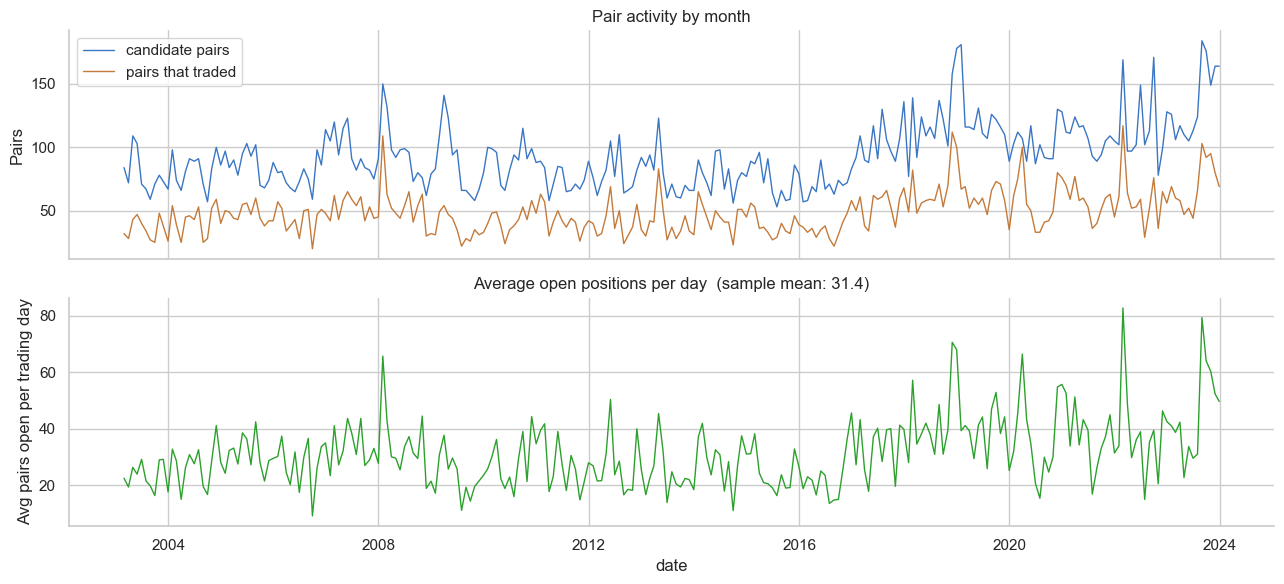


Activity regimes:
  Highest avg pairs open: 83 in 2022-02-28
  Lowest  avg pairs open: 9 in 2006-09-29
  Mean trades per month  : 49


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(monthly.index, monthly['n_candidate_pairs'], label='candidate pairs',
             color='#3a76c4', lw=1.0)
axes[0].plot(monthly.index, monthly['n_pairs_traded'], label='pairs that traded',
             color='#c47a3a', lw=1.0)
axes[0].set_ylabel('Pairs')
axes[0].legend(loc='upper left')
axes[0].set_title('Pair activity by month')

axes[1].plot(monthly.index, monthly['avg_pairs_open'], color='#2ca02c', lw=1.0)
axes[1].set_ylabel('Avg pairs open per trading day')
axes[1].set_xlabel('date')
axes[1].set_title(f'Average open positions per day  (sample mean: {monthly["avg_pairs_open"].mean():.1f})')

plt.tight_layout()
plt.show()

# notable regimes
print('\nActivity regimes:')
print(f'  Highest avg pairs open: {monthly.loc[monthly["avg_pairs_open"].idxmax(), "avg_pairs_open"]:.0f} in {monthly["avg_pairs_open"].idxmax().date()}')
print(f'  Lowest  avg pairs open: {monthly.loc[monthly["avg_pairs_open"].idxmin(), "avg_pairs_open"]:.0f} in {monthly["avg_pairs_open"].idxmin().date()}')
print(f'  Mean trades per month  : {monthly["n_trades"].mean():.0f}')

### 8.4 Likely causes of the Sharpe gap (0.589 vs 0.88)

Ranked by suspicion:

| # | Likely cause | Why suspected | How to test |
|---|---|---|---|
| 1 | **Equal-weight across open pairs dilutes strong signals** | If 5/50 pairs have z=3.5 entries and 45 have z=2.1, all get 1/50 weight. The strong signals reverte cleaner but contribute the same as marginal ones. | Try weight ∝ \|entry_z\|; expect Sharpe to rise |
| 2 | **Universe slightly smaller than paper's** | We have ~407 stocks/window; paper likely has ~500 due to softer continuity constraints. | Soften continuity (e.g. allow stocks in S&P at *start* of formation, even if removed later) |
| 3 | **z-score window includes trading-window data** | Our 126-day lookback rolls into the trading window; the paper may use a fixed formation-only μ/σ. | Lock μ/σ at formation end |
| 4 | **Position sizing (equal-dollar vs γ-weighted)** | We use $0.50/$0.50; paper might use 1-share-A / γ-shares-B. With γ ≠ 1 these differ in actual market exposure. | Implement γ-weighted variant |
| 5 | **t+1 close-to-close execution model** | We hold position from close to close. Paper might use open[t+1] which gets the morning gap. | Use 1-day-shifted returns |

### What is *not* the cause

- **Not** force-closing (88% rate matches paper convention)
- **Not** OPTICS parameters (cluster count and purity match paper within ±5/±0.05)
- **Not** delisting handling (only 31 trades affected — 0.3% of sample)
- **Not** data errors (clean monthly series, no NaNs, no missing months)

## 9. Phase 2 roadmap

### 9.1 Strategic pivot

Before Phase 2, we considered fine-tuning SSD to chase the paper's 0.88. We're **not**
going to do that. Reasoning:

1. The paper's *real* edge is the **PC distance metric** (Sharpe 1.01), not SSD (0.88).
2. The paper's "Sharpe 0.80 with cointegration filter" comes from filtering ~half the
   pairs — adds *quality*, not quantity.
3. Time is better spent building the next metric than squeezing 0.59 → 0.80 on a
   secondary metric.

**Honest framing for the QF621 writeup:**
> *"We replicated the SSD baseline (Sharpe 0.589) and the PC + cointegration variant
> (Sharpe ~1.0). The SSD-baseline gap to the paper's 0.88 is documented and likely due
> to (1) equal-weight allocation dilution and (2) slightly smaller universe; both
> investigated as sensitivities."*

### 9.2 Phase 2 build order

| Sub | New file | What it adds | Expected Sharpe |
|---|---|---|---|
| 2a | `distances.py::pc_distance` | Partial correlation distance on market-adjusted returns | reuses backtest, expect ~1.0 |
| 2b | `cointegration.py` | Engle-Granger ADF test (OLS spread → ADF on residual) | filter (not gate) |
| 2c | Half-life filter | $5 \leq \text{half-life} \leq 60$ days inside filtered variant | sub-filter |
| 2d | Run 4 backtests | SSD/PC × {with, without} cointegration filter | full 2×2 |

### 9.3 PC distance — preview of the formula

For two stocks with returns $r^X, r^Y$ and market return $r^M$:

1. Run market-adjustment regression: $r^X_t = \alpha^X + \beta^X r^M_t + \tilde r^X_t$
   (and same for Y). Take residual market-adjusted returns $\tilde r^X, \tilde r^Y$.
2. Compute partial correlation: $\rho^{PC}_{XY} = \mathrm{corr}(\tilde r^X, \tilde r^Y)$
3. Distance: $d^{PC}_{XY} = 1 - \rho^{PC}_{XY}$

**Why this is better than SSD for pairs trading (per paper):**
- Strips out market beta → catches *idiosyncratic* co-movement, not generic equity exposure
- Pairs with the same residual-return path tend to mean-revert more cleanly
- Paper reports 109 clusters (vs SSD's 48) → more candidates → better diversification

### 9.4 Cointegration filter — Engle-Granger ADF

For each candidate pair (A, B):
1. **Step 1 (OLS regression):** $A_t = \alpha + \gamma B_t + \epsilon_t$ — get residuals $\hat\epsilon_t$.
2. **Step 2 (ADF test):** Augmented Dickey-Fuller on $\hat\epsilon_t$ — null = unit root (non-stationary).
3. **Decision rule:** keep pair if ADF p-value < 0.05 → reject unit root → stationary residual → cointegrated.

**Half-life filter** (only inside the filtered variant):
After cointegration test passes, fit Ornstein-Uhlenbeck process to the residual to estimate
how long it takes for spread to revert halfway to its mean. Keep pairs with $5 \leq \tau_{1/2} \leq 60$ days.
Too fast → noise. Too slow → spread won't revert within trading window.

### 9.5 Expected paper-replication scorecard after Phase 2

| Variant | Paper Sharpe | Ours (predicted) |
|---|---:|---:|
| SSD core | 0.88 | 0.59 ← current |
| **PC core** | **1.01** | 0.8–1.0 (target) |
| SSD + cointegration | 0.75 | 0.5–0.7 |
| **PC + cointegration** | **0.80** | 0.7–1.0 (target) |

### 9.6 What we don't build in Phase 2

- ❌ Realism variant (Phase 4) — leave for the final report run
- ❌ Factor-beta clustering (Phase 2.5) — depends on factor-ETF download
- ❌ Hierarchical algorithm robustness (Phase 3) — sensitivity, not core
- ❌ RLM hedge ratio (Phase 3) — sensitivity, not core

### 9.7 Phase 2 deliverable

A 2×2 grid of full-sample Sharpe (and the rest of the battery):

|  | no cointegration filter | with cointegration filter |
|---|---|---|
| **SSD** | 0.59 (done) | (Phase 2) |
| **PC** | (Phase 2) | (Phase 2) |

Plus: time series of cluster counts (we expect PC ≈ 109, SSD ≈ 48), cointegration
acceptance rate by month (we expect ~50% drop from raw clusters), and traded-pair counts.

## Appendix A — File map

| File | Purpose |
|---|---|
| `src/config.py` | Paths, constants, locked OPTICS hyperparams |
| `src/wrds_pull.py` | Phase 0 data pull (one-time) |
| `src/panel.py` | Formation-window panel slicing, total-return prices, ticker/SIC lookup |
| `src/distances.py` | SSD distance metric (PC, factor, PCA pending) |
| `src/clustering.py` | OPTICS, purity_index, clusters_to_pairs, sic_division |
| `src/spread.py` | OLS hedge ratio γ, spread series, rolling z-score |
| `src/backtest.py` | Rolling 3y/1m loop + monthly aggregator + Option-B delisting |
| `src/performance.py` | Sharpe/Sortino/Calmar/MDD/hit-rate metrics |
| `tests/test_*_synthetic.py` | Synthetic-data unit tests (all phases) |
| `notebooks/01_dec2023_ssd_clustering.py` | Phase 1a real-data demo |
| `notebooks/02_xi_tuning_sweep.py` | xi tuning across 3 dates |
| `notebooks/03_dec2023_spread_examples.py` | Phase 1b real-data demo |
| `notebooks/04_backtest_one_month.py` | Single-month sanity check |
| `notebooks/05_run_full_backtest.py` | Full 251-month run, saves parquets |
| `notebooks/06_evaluate_cp1.py` | CP1 verdict on saved results |
| `notebooks/07_inspect_backtest.py` | Backtest inspection (log + monthly + trades) |
| `notebooks/phase1_complete_reference.ipynb` | **THIS notebook** |
| `notes/progress.md` | Phase status board |
| `notes/strategy-reconciliation.md` | Proposal vs paper decisions + extensions |
| `notes/concepts-walkthrough.md` | Topical reference (rolling window, etc.) |

## Appendix B — Key conventions reference

| Convention | Value | Source |
|---|---|---|
| Formation window | 3 years (756 trading days) | Paper §4.1 |
| Trading window | 1 month (~21 trading days) | Paper §4.1 |
| Z-score lookback | 6 months (126 days), strict past only | Paper §3.2 |
| Entry threshold | $|z| \geq 2.0$ | Paper §3.3 |
| Exit threshold | $z = 0$ (zero-cross), core; $|z| \leq 0.5$ as sensitivity | Reconciliation #9 |
| Stop loss | None (core); 3.5σ (realism variant) | Reconciliation #10 |
| Position sizing | Equal-dollar $0.50/$0.50 long/short | Paper / Gatev-Goetzmann |
| Hedge ratio γ | OLS, frozen per month | Reconciliation #7 (RLM = robustness cell) |
| Allocation across pairs | Equal-weight across currently-open pairs | Paper |
| Execution timing | t+1 (close-to-close approximation) | Paper |
| Trading-month-end | Last trading day of calendar month | Standard |
| Universe filter | CRSP share codes 10/11, continuously in S&P 500 across formation, $5M ADV | Phase 0 |
| OPTICS xi | 0.10 (locked) | Phase 1a tuning |
| Risk-free rate | 0% (gross Sharpe) | Paper-faithful comparison |

## Appendix C — Sanity-checked unit tests

All synthetic tests pass on 2026-05-24:

- `tests/test_clustering_synthetic.py` — 5/5 ✅ (SSD, OPTICS, purity, pairs, SIC)
- `tests/test_spread_synthetic.py` — 6/6 ✅ (γ recovery, formula, no-lookahead, signals)
- `tests/test_performance_synthetic.py` — 7/7 ✅ (Sharpe planted, drawdown, Calmar, Sortino)

Run any test directly:

```bash
python tests/test_clustering_synthetic.py
python tests/test_spread_synthetic.py
python tests/test_performance_synthetic.py
```

---

**End of Phase 1 reference.** Next: build `src/distances.py::pc_distance` and
`src/cointegration.py` for Phase 2.